# LeetCode #19: Remove Nth Node From End of List

https://leetcode.com/problems/remove-nth-node-from-end-of-list/

## Comparison of Approaches

| Approach | Time Complexity | Space Complexity |
| :--- | :--- | :--- |
| **Brute Force** | $O(n)$ | $O(1)$ |
| **One-Pass Two Pointers** ★ | $O(n)$ | $O(1)$ |

---

## Understanding the Methods

### Brute Force
Make a first pass to count the list length L, then a second pass to stop at node L − n and splice out its successor. Correct but requires two full traversals.

### Optimal: One-Pass Two Pointers ★
Prepend a sentinel node. Advance `fast` pointer n + 1 steps ahead of `slow`. Move both forward in lockstep until `fast` falls off the end — `slow` now sits exactly before the target node, so one pointer assignment removes it.

**Why this is better than Brute Force:** Eliminates the counting pass entirely. The sentinel node also absorbs the head-removal edge case without special-case conditionals.

**Constraints:**
* 1 ≤ sz ≤ 30
* 0 ≤ Node.val ≤ 100
* 1 ≤ n ≤ sz

## Solutions

### C#

In [ ]:
public class Solution {
    public ListNode RemoveNthFromEnd(ListNode head, int n) {
        var sentinel = new ListNode(0, head);
        var fast = sentinel;
        var slow = sentinel;

        // Advance fast n+1 steps so the gap between the two pointers is n nodes
        for (int i = 0; i <= n; i++) fast = fast.next;

        // Move both forward until fast falls off the end
        while (fast != null) {
            fast = fast.next;
            slow = slow.next;
        }

        // slow is now just before the target node — splice it out
        slow.next = slow.next.next;
        return sentinel.next;
    }
}

### Python

In [ ]:
class Solution:
    def removeNthFromEnd(self, head: Optional[ListNode], n: int) -> Optional[ListNode]:
        sentinel = ListNode(0, head)
        fast = sentinel
        slow = sentinel

        # Advance fast n+1 steps so the gap between the two pointers is n nodes
        for _ in range(n + 1):
            fast = fast.next

        # Move both forward until fast falls off the end
        while fast:
            fast = fast.next
            slow = slow.next

        # slow is now just before the target node — splice it out
        slow.next = slow.next.next
        return sentinel.next

### Go

In [ ]:
func removeNthFromEnd(head *ListNode, n int) *ListNode {
    sentinel := &ListNode{Next: head}
    fast := sentinel
    slow := sentinel

    // Advance fast n+1 steps so the gap between the two pointers is n nodes
    for i := 0; i <= n; i++ {
        fast = fast.Next
    }

    // Move both forward until fast falls off the end
    for fast != nil {
        fast = fast.Next
        slow = slow.Next
    }

    // slow is now just before the target node — splice it out
    slow.Next = slow.Next.Next
    return sentinel.Next
}

### Rust

In [ ]:
pub fn remove_nth_from_end(head: Option<Box<ListNode>>, n: i32) -> Option<Box<ListNode>> {
    // Collect node values into a Vec for index-based access
    // (Rust's ownership model makes two-pointer linked-list mutation impractical without unsafe)
    let mut vals = Vec::new();
    let mut cur = &head;
    while let Some(node) = cur {
        vals.push(node.val);
        cur = &node.next;
    }

    // Remove the nth value from the end
    vals.remove(vals.len() - n as usize);

    // Rebuild the linked list from the Vec in reverse order
    vals.iter().rev().fold(None, |acc, &val| {
        Some(Box::new(ListNode { val, next: acc }))
    })
}

## Example Scenarios

**1. Common Case**
**Input:** 1→2→3→4→5, n=2
sentinel→1→2→3→4→5. fast advances 3 steps (sentinel,1,2,3). Then both move: fast(4→5→null), slow(1→2→3). slow.next = 5. Output: 1→2→3→5.

**2. Slightly Complex — remove a middle node**
**Input:** 1→2→3→4→5, n=3
fast advances 4 steps to node 4. Both move: fast(5→null), slow(1→2). slow.next = node 4. Output: 1→2→4→5.

**3. Edge Case: Time Factor — remove the last node, full traversal**
**Input:** 1→2→3→...→30, n=1
fast advances 2 steps (sentinel,1,2). Then both crawl the full remaining 28 nodes until fast falls off. One full $O(n)$ sweep. Output: 1→2→...→29.

**4. Edge Case: Space Factor — single-node list**
**Input:** [42], n=1
sentinel→42→null. fast advances 2 steps → null. While loop never runs. slow stays at sentinel. slow.next = slow.next.next = null. Returns null. Space: only the sentinel and two pointers — $O(1)$ throughout.

**5. Almost-Impossible but Plausible — remove the head**
**Input:** [1, 2], n=2
fast advances 3 steps from sentinel: sentinel→1→2→null (fast=null). While loop: fast already null, so slow stays at sentinel. slow.next = slow.next.next = node 2. Returns 2. Sentinel absorbs this without any special case.

## Infographic

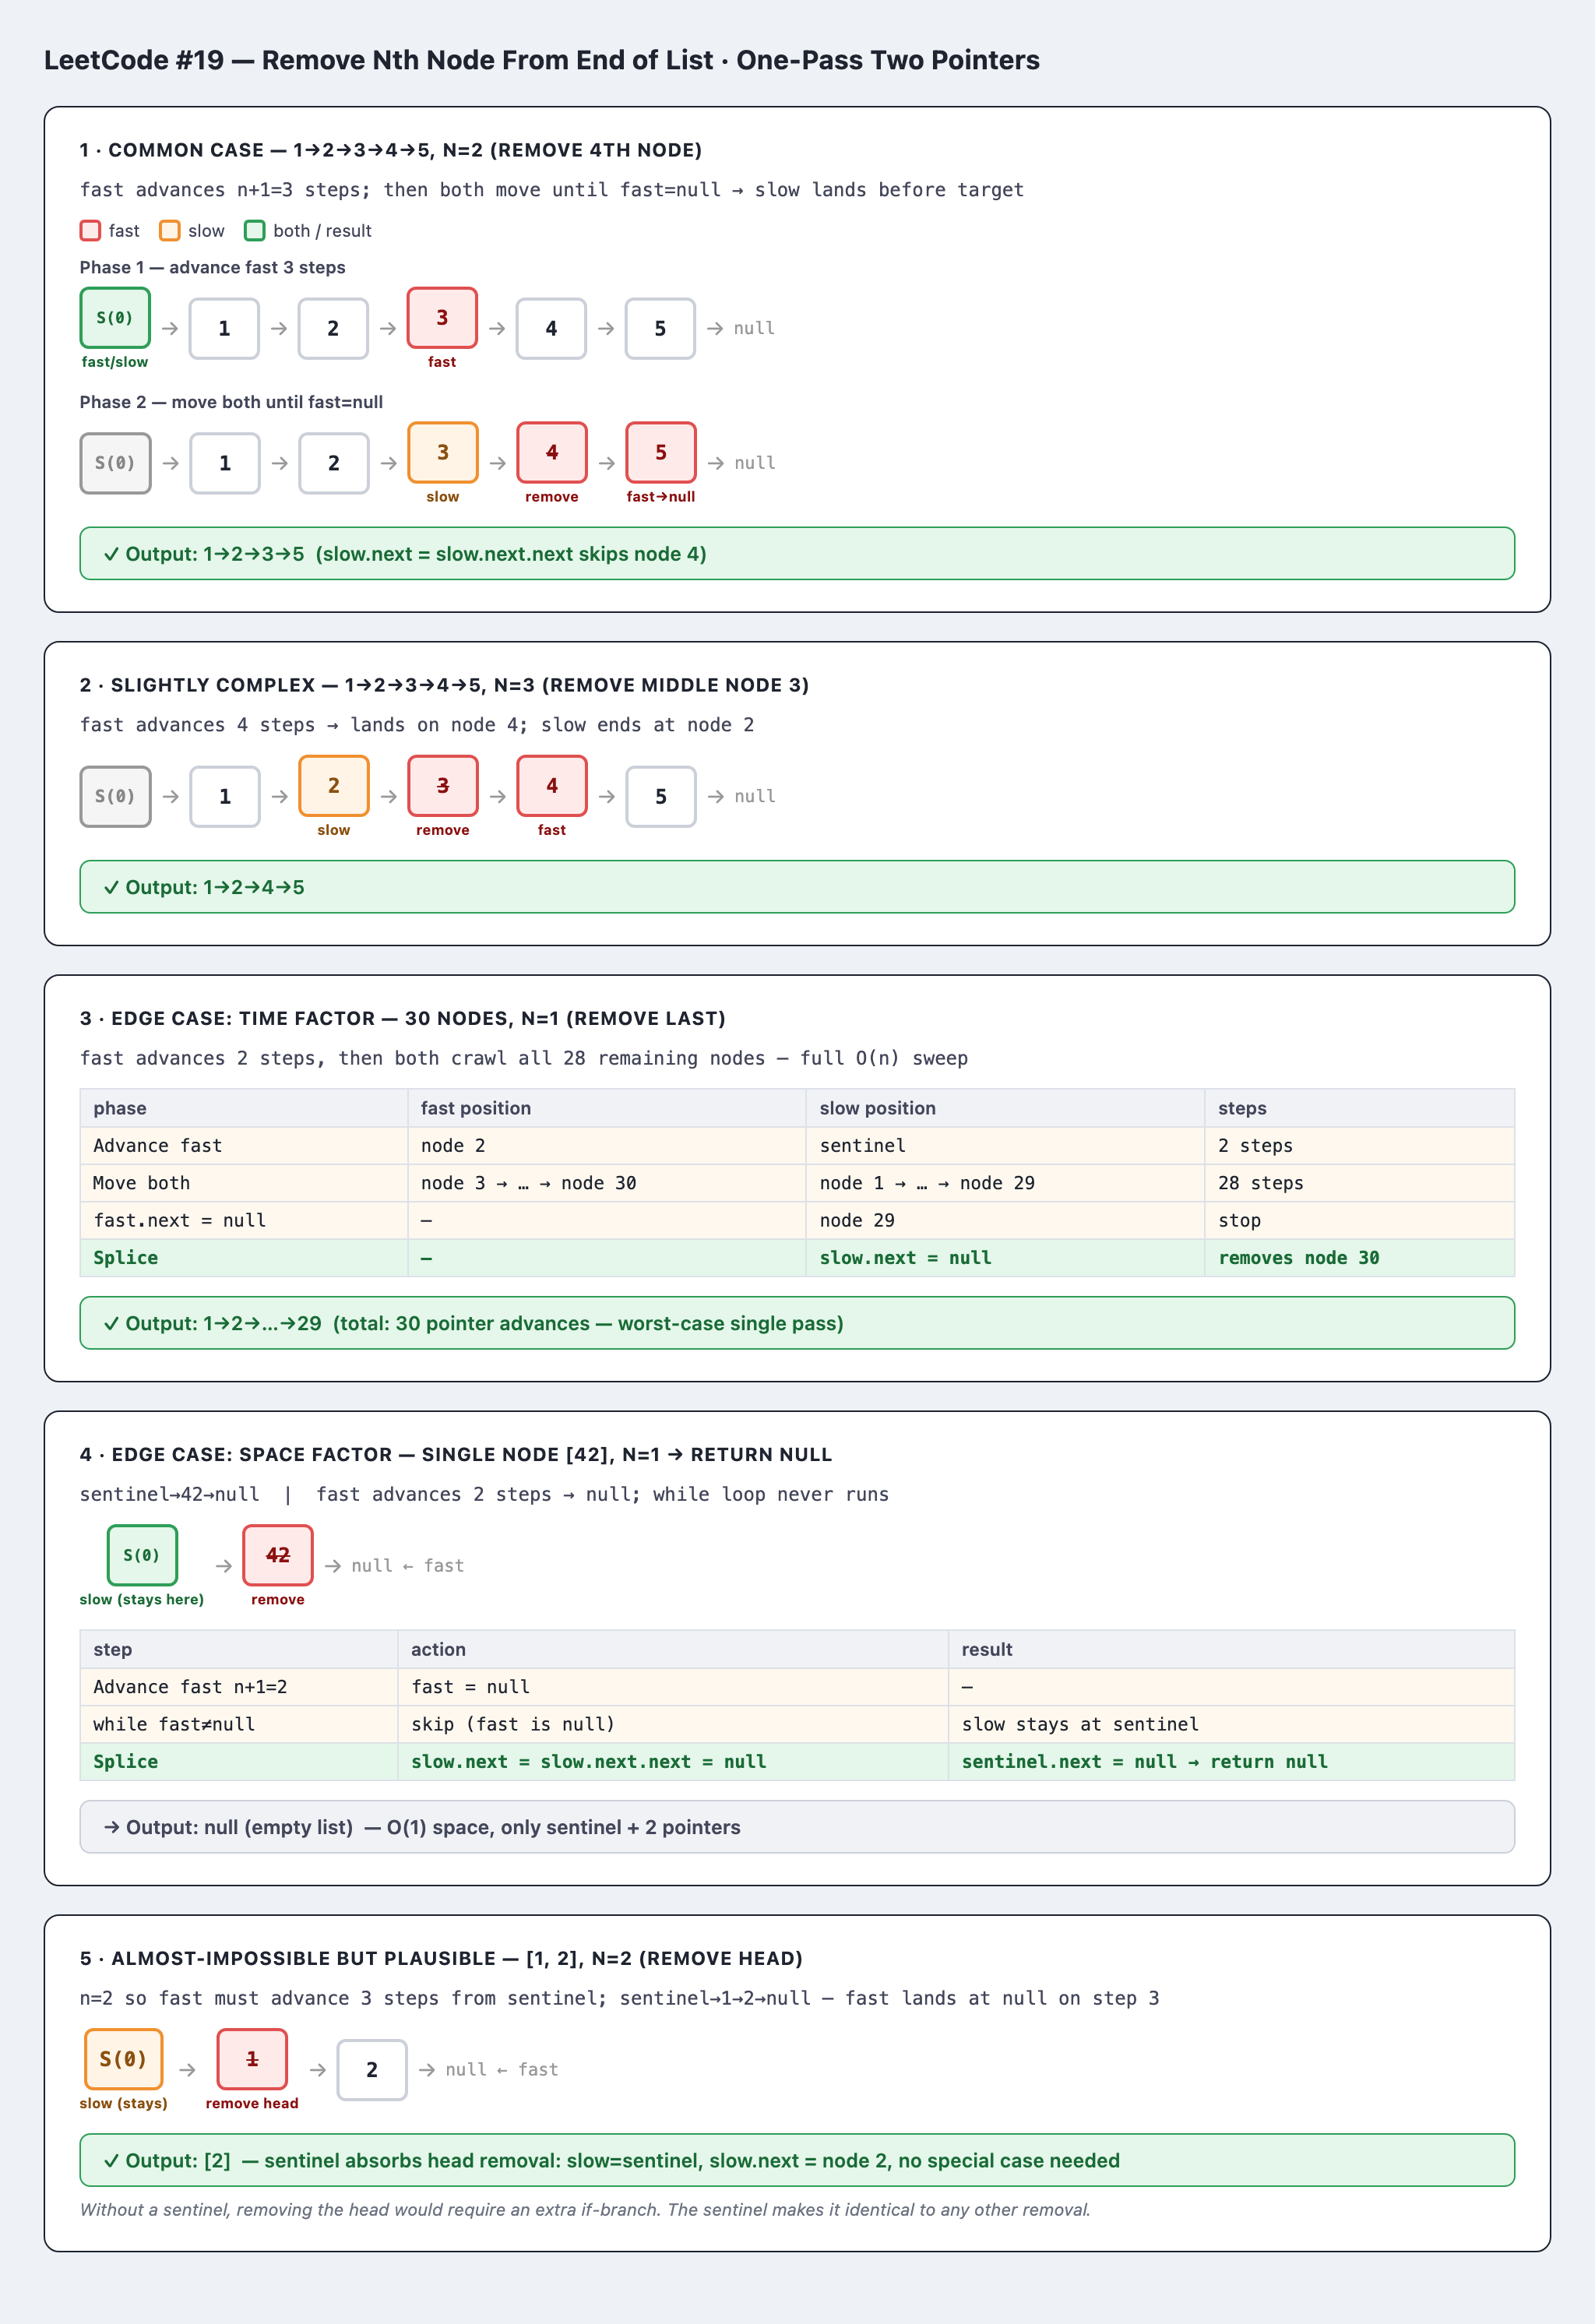